In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns


In [36]:
df=pd.read_csv('./data/custom_accident_dataset_ready.csv')
df.head()

,accelX,accelY,accelZ,gyroX,gyroY,gyroZ,"weather_condition_BLOWING SAND, SOIL, DIRT",weather_condition_BLOWING SNOW,weather_condition_CLEAR,weather_condition_CLOUDY/OVERCAST,...,roadway_surface_cond_DRY,roadway_surface_cond_ICE,roadway_surface_cond_OTHER,"roadway_surface_cond_SAND, MUD, DIRT",roadway_surface_cond_SNOW OR SLUSH,roadway_surface_cond_UNKNOWN,roadway_surface_cond_WET,crash_type_INJURY AND / OR TOW DUE TO CRASH,crash_type_NO INJURY / DRIVE AWAY,class
0,-0.244069,8.094744e-02,9.807350,0.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,False,False,True,0
1,-0.206027,-9.387732e-07,9.807837,0.0,0.0,0.0,False,False,True,False,...,False,False,False,False,False,True,False,False,True,0
2,-0.226992,-3.950313e-02,9.807553,0.0,0.0,0.0,False,False,False,False,...,False,False,False,False,False,True,False,False,True,0
3,-0.225045,4.047326e-02,9.807437,0.0,0.0,0.0,False,False,False,False,...,False,False,False,False,False,False,True,False,True,0
4,-0.226992,-3.950313e-02,9.807553,0.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,False,False,True,0


In [37]:
df=df[['accelX', 'accelY', 'accelZ', 'gyroX', 'gyroY', 'gyroZ','class']]


In [38]:
df['class'].value_counts()

class
1    85620
0    13738
Name: count, dtype: int64

In [39]:
df_class_0 = df[df['class'] == 0]
df_class_1 = df[df['class'] == 1]
df_class_1_down = df_class_1.sample(
    n=len(df_class_0),
    random_state=42
)

# Combine
df_balanced = pd.concat([df_class_0, df_class_1_down])

# Shuffle
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check
print(df_balanced['class'].value_counts())

class
1    13738
0    13738
Name: count, dtype: int64


In [40]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier


In [41]:
X = df_balanced.drop(columns=['class'])
y = df_balanced['class']


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [43]:
# class 0 = minority, class 1 = majority
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)


scale_pos_weight: 1.0


In [44]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)


In [45]:
xgb_model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [46]:
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]


In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7139737991266376
ROC-AUC: 0.7893548755320794

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.73      0.72      2748
           1       0.72      0.70      0.71      2748

    accuracy                           0.71      5496
   macro avg       0.71      0.71      0.71      5496
weighted avg       0.71      0.71      0.71      5496


Confusion Matrix:
 [[2008  740]
 [ 832 1916]]


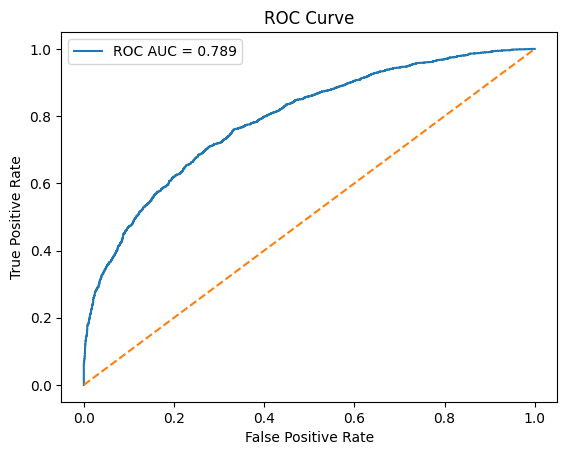

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


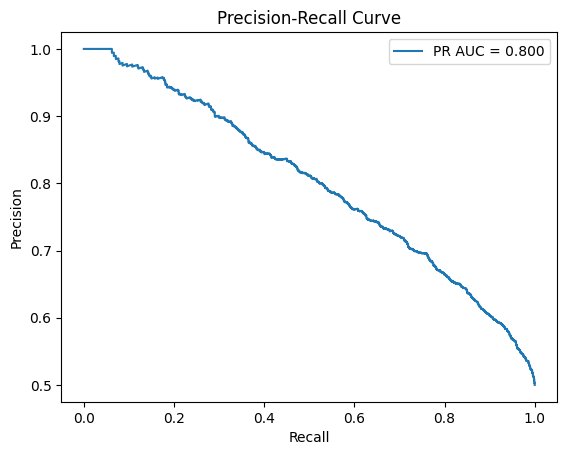

In [49]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

plt.figure()
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


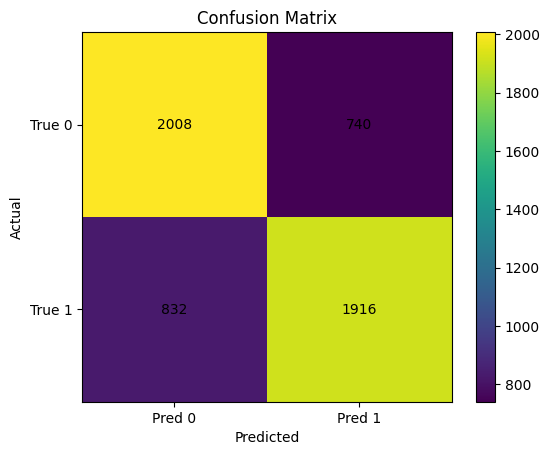

In [50]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


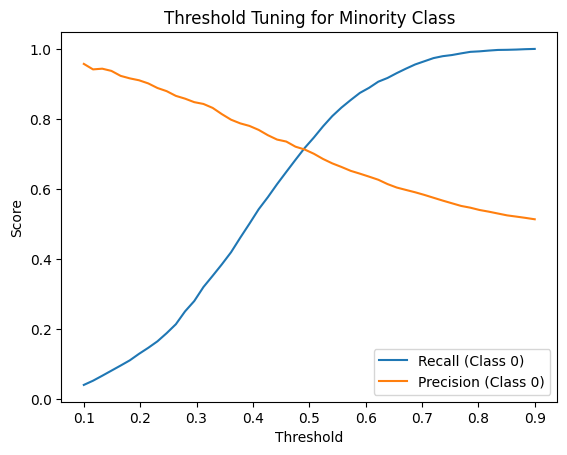

In [51]:
thresholds = np.linspace(0.1, 0.9, 50)
recalls = []
precisions = []

for t in thresholds:
    preds = (y_pred_proba >= t).astype(int)
    recalls.append(
        (confusion_matrix(y_test, preds)[0,0]) /
        (confusion_matrix(y_test, preds)[0].sum())
    )
    precisions.append(
        (confusion_matrix(y_test, preds)[0,0]) /
        (confusion_matrix(y_test, preds)[:,0].sum())
    )

plt.figure()
plt.plot(thresholds, recalls, label="Recall (Class 0)")
plt.plot(thresholds, precisions, label="Precision (Class 0)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning for Minority Class")
plt.legend()
plt.show()


In [52]:
import pickle

# Save model
with open("xgboost_accident_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("Model saved successfully!")


Model saved successfully!
